# Trực quan số lượng

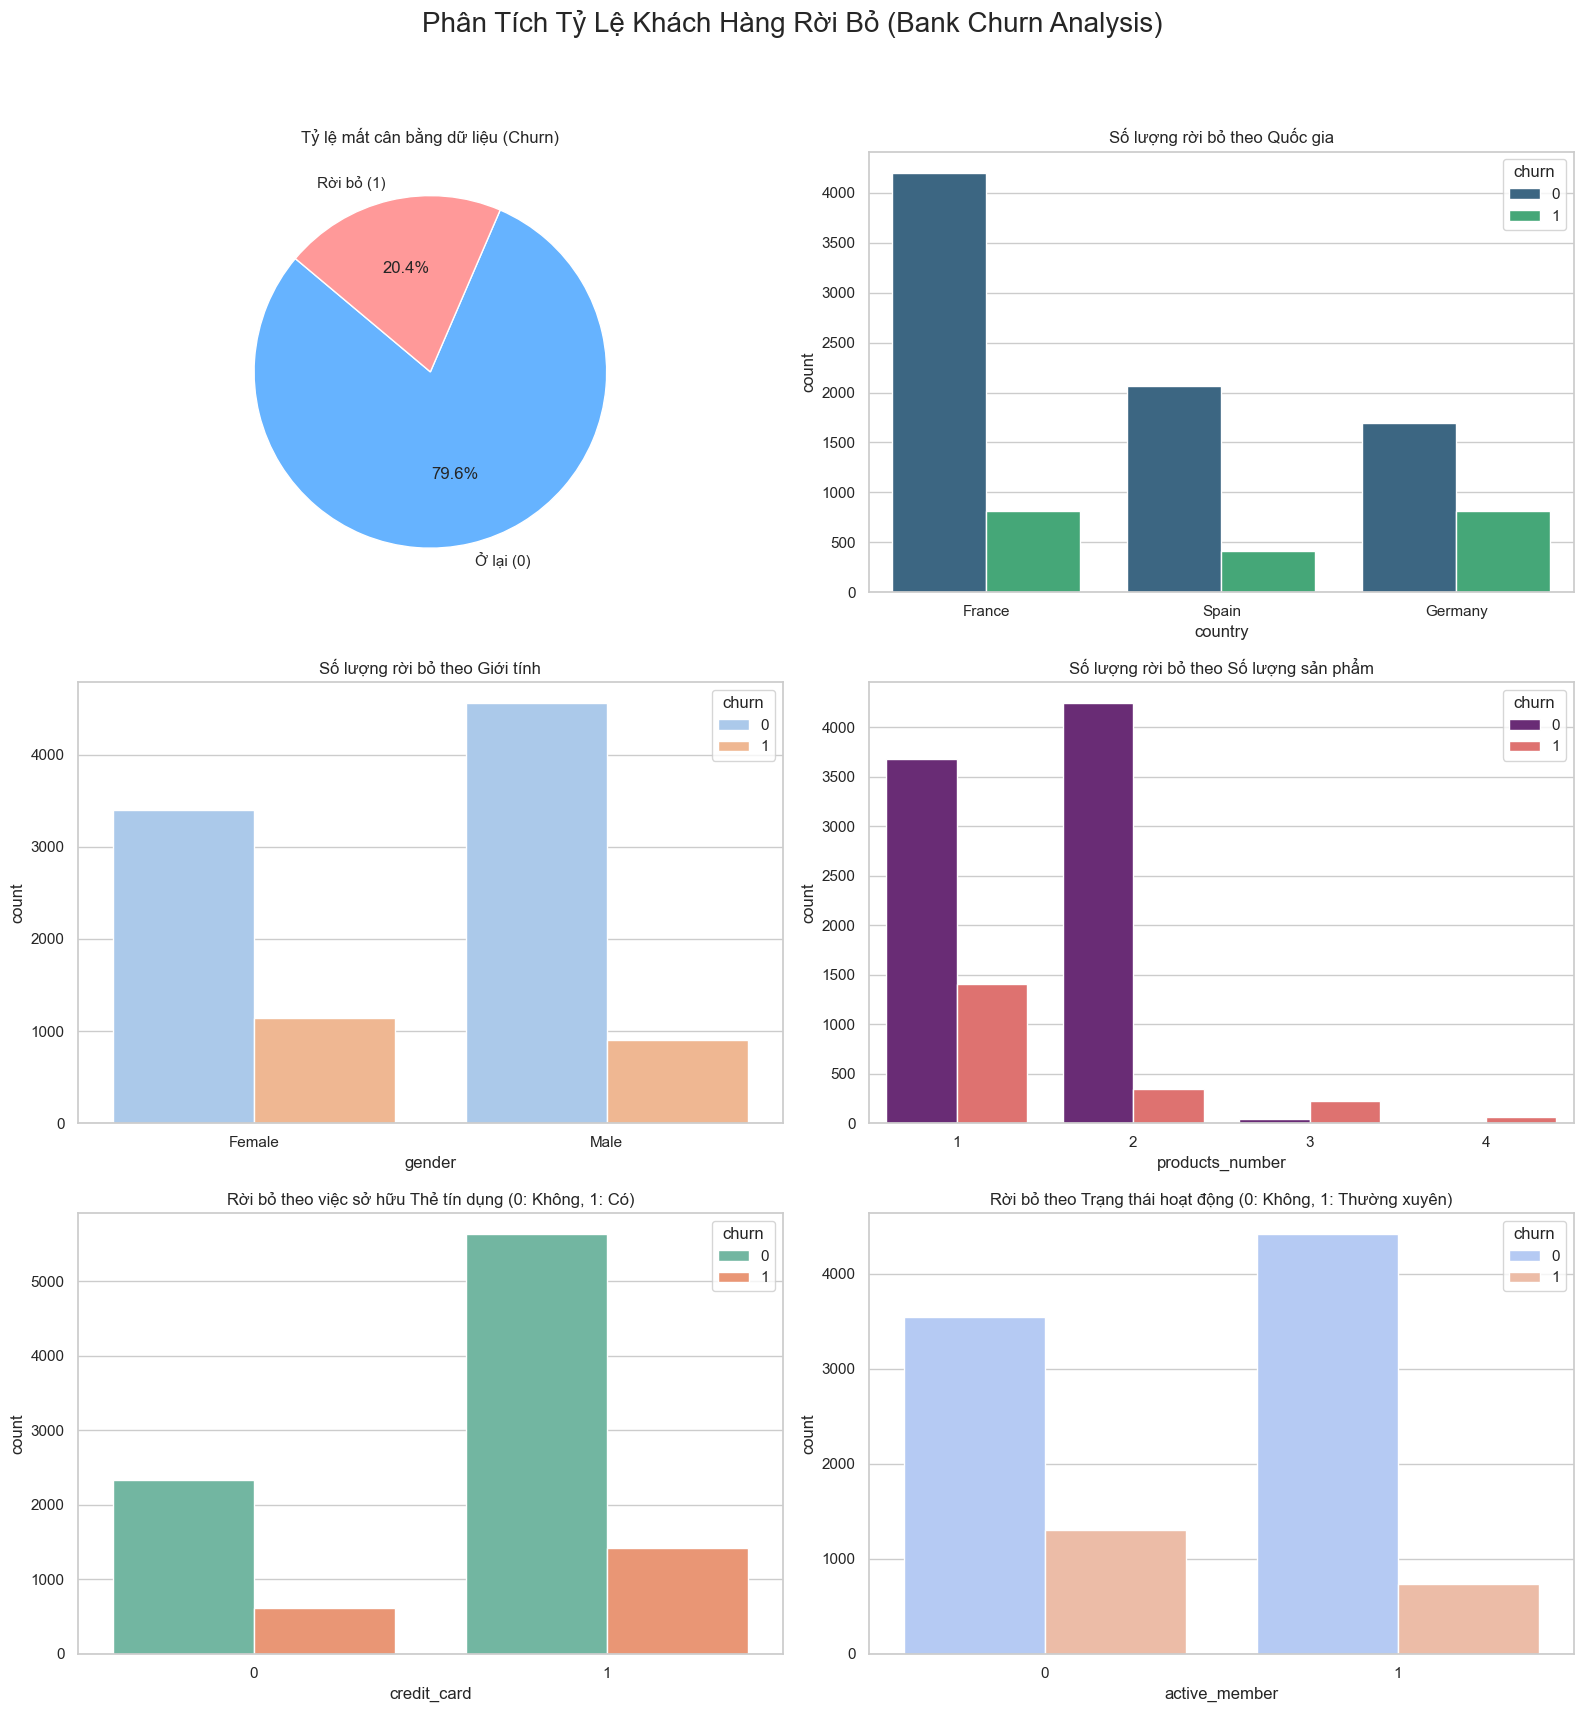

--- THỐNG KÊ CHI TIẾT ---
Tổng số lượng khách hàng: 10000
Số lượng khách hàng rời bỏ (Churn): 2037
Số lượng khách hàng ở lại: 7963
Tỷ lệ mất cân bằng: 20.37% dữ liệu là khách hàng rời bỏ.

Tỷ lệ % rời bỏ theo từng đặc điểm:
------------------------------
Theo Quốc gia:
country
France     16.154767
Germany    32.443204
Spain      16.673395
Name: churn, dtype: float64

Theo Số lượng sản phẩm:
products_number
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: churn, dtype: float64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# Thiết lập phong cách cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

# 2. Đánh giá mức độ mất cân bằng của dữ liệu (Churn vs Non-Churn)
churn_counts = df['churn'].value_counts()
churn_labels = ['Ở lại (0)', 'Rời bỏ (1)']

# 3. Phân tích trực quan hóa
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Phân Tích Tỷ Lệ Khách Hàng Rời Bỏ (Bank Churn Analysis)', fontsize=20)

# --- Biểu đồ 1: Mức độ mất cân bằng dữ liệu ---
axes[0, 0].pie(churn_counts, labels=churn_labels, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
axes[0, 0].set_title('Tỷ lệ mất cân bằng dữ liệu (Churn)')

# --- Biểu đồ 2: Churn theo Quốc gia ---
sns.countplot(x='country', hue='churn', data=df, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Số lượng rời bỏ theo Quốc gia')

# --- Biểu đồ 3: Churn theo Giới tính ---
sns.countplot(x='gender', hue='churn', data=df, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Số lượng rời bỏ theo Giới tính')

# --- Biểu đồ 4: Churn theo Số lượng sản phẩm ---
sns.countplot(x='products_number', hue='churn', data=df, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Số lượng rời bỏ theo Số lượng sản phẩm')

# --- Biểu đồ 5: Churn theo Thẻ tín dụng (credit_card) ---
sns.countplot(x='credit_card', hue='churn', data=df, ax=axes[2, 0], palette='Set2')
axes[2, 0].set_title('Rời bỏ theo việc sở hữu Thẻ tín dụng (0: Không, 1: Có)')

# --- Biểu đồ 6: Churn theo Hoạt động thường xuyên (active_member) ---
sns.countplot(x='active_member', hue='churn', data=df, ax=axes[2, 1], palette='coolwarm')
axes[2, 1].set_title('Rời bỏ theo Trạng thái hoạt động (0: Không, 1: Thường xuyên)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4. In báo cáo thống kê nhanh
print("--- THỐNG KÊ CHI TIẾT ---")
print(f"Tổng số lượng khách hàng: {len(df)}")
print(f"Số lượng khách hàng rời bỏ (Churn): {churn_counts[1]}")
print(f"Số lượng khách hàng ở lại: {churn_counts[0]}")
print(f"Tỷ lệ mất cân bằng: {round(churn_counts[1]/len(df)*100, 2)}% dữ liệu là khách hàng rời bỏ.")

# Tính tỷ lệ % rời bỏ theo từng nhóm để có cái nhìn sâu hơn
def get_churn_rate(feature):
    rate = df.groupby(feature)['churn'].mean() * 100
    return rate

print("\nTỷ lệ % rời bỏ theo từng đặc điểm:")
print("-" * 30)
print(f"Theo Quốc gia:\n{get_churn_rate('country')}")
print(f"\nTheo Số lượng sản phẩm:\n{get_churn_rate('products_number')}")